In [ ]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

In [ ]:
CAPTURES_DIR = Path("build/debug/captures")

frames = sorted(
    {int(m.group(1)) for p in CAPTURES_DIR.glob("frame_*.bmp")
     if (m := re.search(r'frame_(\d+)', p.name))},
    reverse=True
)
print(f"{len(frames)} capture(s): {[f'frame_{i:04d}' for i in frames]}")

def load_frame(idx):
    stem = CAPTURES_DIR / f"frame_{idx:04d}"
    return (
        np.array(Image.open(f"{stem}_ssaa.bmp").convert("RGB")),
        np.array(Image.open(f"{stem}_aliased.bmp").convert("RGB")),
        np.load(f"{stem}_depth.npy"),
    )

def show_frame(idx):
    ssaa, aliased, depth = load_frame(idx)
    mask  = depth < 1.0
    vals  = depth[mask]
    d_vis = np.where(mask, depth, np.nan)

    fig = plt.figure(figsize=(18, 5))
    fig.suptitle(f"frame_{idx:04d}  —  800×450", fontsize=13, y=1.01)
    gs = gridspec.GridSpec(1, 4, figure=fig, wspace=0.35)

    ax = fig.add_subplot(gs[0]); ax.imshow(ssaa);    ax.set_title("SSAA");    ax.axis("off")
    ax = fig.add_subplot(gs[1]); ax.imshow(aliased); ax.set_title("Aliased"); ax.axis("off")

    ax = fig.add_subplot(gs[2])
    im = ax.imshow(d_vis, cmap="viridis_r", vmin=vals.min(), vmax=vals.max())
    ax.set_title("Depth (D32_FLOAT)"); ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax = fig.add_subplot(gs[3])
    ax.hist(vals, bins=64, color="steelblue", edgecolor="none")
    ax.set_title("Depth histogram"); ax.set_xlabel("depth"); ax.set_ylabel("pixels")
    ax.text(0.97, 0.97, f"min {vals.min():.4f}\nmax {vals.max():.4f}\nμ {vals.mean():.4f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            bbox=dict(boxstyle="round", fc="white", alpha=0.7))

    plt.tight_layout()
    plt.show()
    print(f"  object pixels: {mask.sum():,}/{depth.size:,} ({100*mask.mean():.1f}%)")

C:\Users\magno\AppData\Local\Temp\ipykernel_14044\1128938162.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


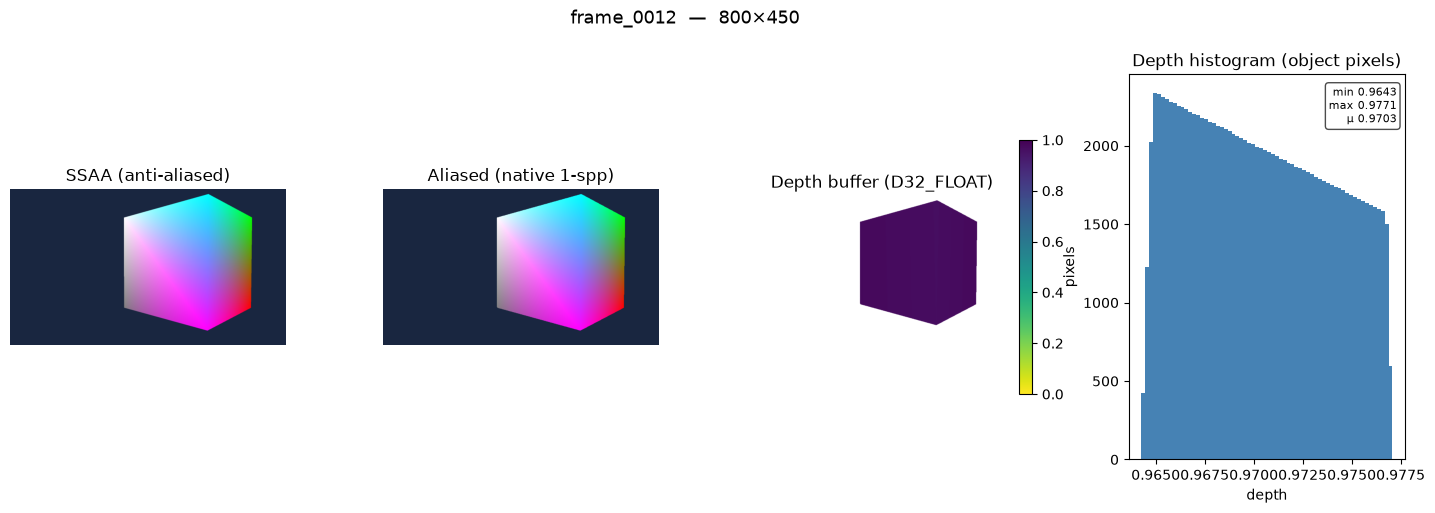

  object pixels: 121,382 / 360,000  (33.7%)


In [9]:
# show the most recent capture
if frames:
    show_frame(frames[0])
else:
    print("No captures found. Press C in the app to capture a frame.")

In [ ]:
if frames:
    show_frame(frames[0])
else:
    print("No captures found. Press C in the app to capture a frame.")